# CarDD — сравнение YOLOv8 vs RT-DETR и WBF-ансамбль

**План:**
1. Загрузка сохраненных метрик и сырых предсказаний обеих моделей
2. Честное сравнение по метрикам (mAP, скорость, эффект TTA)
3. Ground truth для val/test
4. WBF: подбор веса на val
5. Финальная оценка ансамбля на тесте
6. Визуальное сравнение (YOLOv8 / RT-DETR / WBF)
7. Выводы


## 1. Установка и импорты

In [1]:
!pip install ensemble-boxes torchmetrics --quiet

In [2]:
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import seaborn as sns
import torch

from ensemble_boxes import weighted_boxes_fusion
from torchmetrics.detection.mean_ap import MeanAveragePrecision

import warnings
warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")

In [3]:
DATA_DIR = "/kaggle/input/datasets/gabrielfcarvalho/cardd-with-yolo-annotations-images-labels"
YOLO_DIR = "/kaggle/input/datasets/evelonk/yolov8-cardd-results"      
RTDETR_DIR = "/kaggle/input/datasets/evelonk/rtdetr-cardd-results"     

CLASS_NAMES = ["dent", "scratch", "crack", "glass shatter", "lamp broken", "tire flat"]
NUM_CLASSES = len(CLASS_NAMES)

## 2. Загрузка сохраненных результатов

In [6]:
yolo_summary = pd.read_csv(f"{YOLO_DIR}/yolov8_summary.csv")
rtdetr_summary = pd.read_csv(f"{RTDETR_DIR}/rtdetr_summary-2.csv")
yolo_per_class = pd.read_csv(f"{YOLO_DIR}/yolov8_per_class_ap.csv")
rtdetr_per_class = pd.read_csv(f"{RTDETR_DIR}/rtdetr_per_class_ap.csv")

with open(f"{YOLO_DIR}/yolov8_val_preds.json") as f:
    yolo_val_preds = json.load(f)
with open(f"{YOLO_DIR}/yolov8_test_preds.json") as f:
    yolo_test_preds = json.load(f)
with open(f"{RTDETR_DIR}/rtdetr_val_preds.json") as f:
    rtdetr_val_preds = json.load(f)
with open(f"{RTDETR_DIR}/rtdetr_test_preds.json") as f:
    rtdetr_test_preds = json.load(f)

print("YOLOv8 val/test предсказаний:", len(yolo_val_preds), "/", len(yolo_test_preds))
print("RT-DETR val/test предсказаний:", len(rtdetr_val_preds), "/", len(rtdetr_test_preds))

YOLOv8 val/test предсказаний: 810 / 374
RT-DETR val/test предсказаний: 810 / 374


## 3. Проверка


In [7]:
val_files_match = set(yolo_val_preds.keys()) == set(rtdetr_val_preds.keys())
test_files_match = set(yolo_test_preds.keys()) == set(rtdetr_test_preds.keys())
print(f"Val-файлы совпадают: {val_files_match}")
print(f"Test-файлы совпадают: {test_files_match}")

val_image_files = sorted(set(yolo_val_preds.keys()) & set(rtdetr_val_preds.keys()))
test_image_files = sorted(set(yolo_test_preds.keys()) & set(rtdetr_test_preds.keys()))
print(f"Общих изображений: val={len(val_image_files)}, test={len(test_image_files)}")

Val-файлы совпадают: True
Test-файлы совпадают: True
Общих изображений: val=810, test=374


## 4. Сравнение индивидуальных моделей по метрикам

In [8]:
individual_comparison = pd.concat([yolo_summary, rtdetr_summary], ignore_index=True)
individual_comparison = individual_comparison.sort_values("mAP50_tta", ascending=False)
individual_comparison

,model,mAP50_no_tta,mAP50_95_no_tta,mAP50_tta,mAP50_95_tta,inference_ms,train_minutes
0,YOLOv8s,0.73338,0.582884,0.747563,0.597605,7.141625,97.825515
1,"RT-DETR-R18 (HF, custom loop)",0.59118,0.469199,0.619976,0.481448,22.975951,NaN


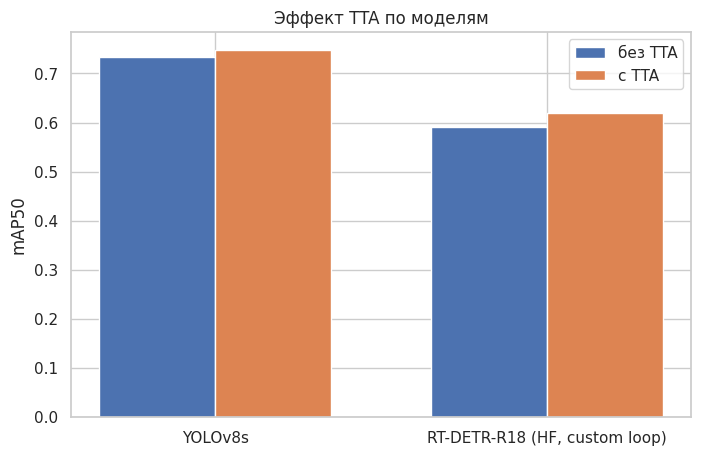

In [9]:
fig, ax = plt.subplots(figsize=(8, 5))
x = np.arange(2)
width = 0.35
ax.bar(x - width/2, individual_comparison["mAP50_no_tta"], width, label="без TTA", color="#4C72B0")
ax.bar(x + width/2, individual_comparison["mAP50_tta"], width, label="с TTA", color="#DD8452")
ax.set_xticks(x)
ax.set_xticklabels(individual_comparison["model"])
ax.set_ylabel("mAP50")
ax.set_title("Эффект TTA по моделям")
ax.legend()
plt.show()

## 5. Ground truth для val/test — из файлов разметки

WBF и честная оценка mAP нуждаются в метках


In [10]:
def load_ground_truth(labels_dir, image_files):
    ground_truth = {}
    for fname in image_files:
        label_path = f"{labels_dir}/{fname.rsplit('.', 1)[0]}.txt"
        boxes, labels = [], []
        if os.path.exists(label_path):
            with open(label_path) as f:
                for line in f:
                    parts = line.strip().split()
                    if len(parts) != 5:
                        continue
                    cls_id, xc, yc, w, h = map(float, parts)
                    x1, y1 = xc - w / 2, yc - h / 2
                    x2, y2 = xc + w / 2, yc + h / 2
                    boxes.append([x1, y1, x2, y2])
                    labels.append(int(cls_id))
        ground_truth[fname] = {"boxes": boxes, "labels": labels}
    return ground_truth

In [11]:
val_gt = load_ground_truth(f"{DATA_DIR}/val/labels", val_image_files)
test_gt = load_ground_truth(f"{DATA_DIR}/test/labels", test_image_files)
print("Ground truth готов для val и test")

Ground truth готов для val и test


## 6. Функция честной оценки mAP через torchmetrics

Используется `torchmetrics`

In [12]:
def evaluate_map(predictions, ground_truth, image_files):
    metric = MeanAveragePrecision(iou_type="bbox", box_format="xyxy", class_metrics=True)
    preds_list, targets_list = [], []
    for fname in image_files:
        p = predictions[fname]
        g = ground_truth[fname]
        preds_list.append({
            "boxes": torch.tensor(p["boxes"], dtype=torch.float32) if p["boxes"] else torch.zeros((0, 4)),
            "scores": torch.tensor(p["scores"], dtype=torch.float32) if p["scores"] else torch.zeros((0,)),
            "labels": torch.tensor(p["labels"], dtype=torch.int64) if p["labels"] else torch.zeros((0,), dtype=torch.int64),
        })
        targets_list.append({
            "boxes": torch.tensor(g["boxes"], dtype=torch.float32) if g["boxes"] else torch.zeros((0, 4)),
            "labels": torch.tensor(g["labels"], dtype=torch.int64) if g["labels"] else torch.zeros((0,), dtype=torch.int64),
        })
    metric.update(preds_list, targets_list)
    return metric.compute()

## 7. WBF — подбор веса на val

Перебор нескольких комбинаций весов (YOLOv8 / RT-DETR), для каждой
объединение предсказаний через WBF на **val**, оценивание mAP50, выбор
лучшей комбинации

In [13]:
def apply_wbf(preds_a, preds_b, image_files, weight_a, weight_b, iou_thr=0.5, skip_box_thr=0.0001):
    fused = {}
    for fname in image_files:
        pa, pb = preds_a[fname], preds_b[fname]
        boxes, scores, labels = weighted_boxes_fusion(
            [pa["boxes"], pb["boxes"]],
            [pa["scores"], pb["scores"]],
            [pa["labels"], pb["labels"]],
            weights=[weight_a, weight_b],
            iou_thr=iou_thr, skip_box_thr=skip_box_thr,
        )
        fused[fname] = {"boxes": boxes.tolist(), "scores": scores.tolist(), "labels": labels.astype(int).tolist()}
    return fused

In [14]:
weight_options = [(0.2, 0.8), (0.3, 0.7), (0.4, 0.6), (0.5, 0.5), (0.6, 0.4), (0.7, 0.3), (0.8, 0.2)]
search_results = []

for w_yolo, w_rtdetr in weight_options:
    fused_val = apply_wbf(yolo_val_preds, rtdetr_val_preds, val_image_files, w_yolo, w_rtdetr)
    val_map = evaluate_map(fused_val, val_gt, val_image_files)
    search_results.append({
        "weight_yolo": w_yolo, "weight_rtdetr": w_rtdetr,
        "val_mAP50": val_map["map_50"].item(),
    })
    print(f"YOLOv8={w_yolo} / RT-DETR={w_rtdetr} -> val mAP50 = {val_map['map_50'].item():.4f}")

search_df = pd.DataFrame(search_results)
best_row = search_df.loc[search_df["val_mAP50"].idxmax()]
BEST_W_YOLO, BEST_W_RTDETR = best_row["weight_yolo"], best_row["weight_rtdetr"]
print(f"\nЛучшая комбинация: YOLOv8={BEST_W_YOLO}, RT-DETR={BEST_W_RTDETR} (val mAP50={best_row['val_mAP50']:.4f})")

YOLOv8=0.2 / RT-DETR=0.8 -> val mAP50 = 0.3546
YOLOv8=0.3 / RT-DETR=0.7 -> val mAP50 = 0.4297
YOLOv8=0.4 / RT-DETR=0.6 -> val mAP50 = 0.4882
YOLOv8=0.5 / RT-DETR=0.5 -> val mAP50 = 0.5255
YOLOv8=0.6 / RT-DETR=0.4 -> val mAP50 = 0.5488
YOLOv8=0.7 / RT-DETR=0.3 -> val mAP50 = 0.5624
YOLOv8=0.8 / RT-DETR=0.2 -> val mAP50 = 0.5638

Лучшая комбинация: YOLOv8=0.8, RT-DETR=0.2 (val mAP50=0.5638)


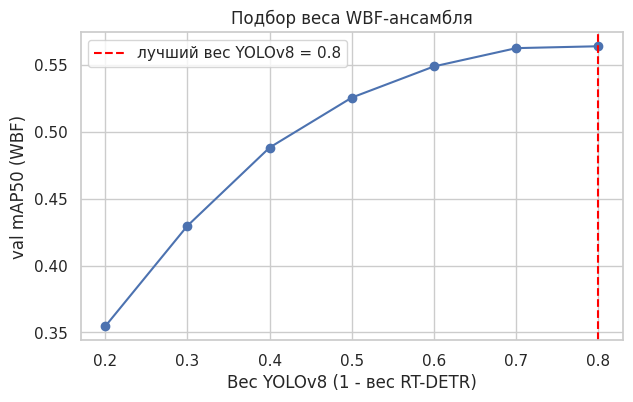

In [15]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(search_df["weight_yolo"], search_df["val_mAP50"], marker="o", color="#4C72B0")
ax.axvline(BEST_W_YOLO, linestyle="--", color="red", label=f"лучший вес YOLOv8 = {BEST_W_YOLO}")
ax.set_xlabel("Вес YOLOv8 (1 - вес RT-DETR)")
ax.set_ylabel("val mAP50 (WBF)")
ax.set_title("Подбор веса WBF-ансамбля")
ax.legend()
plt.show()

In [ ]:
в целом такой результат логичный, потому что качество YOLOv8 сильно лучше RT-DETR, поэтому получилось именно такое распределение весов

## 8. Финальная оценка WBF-ансамбля на тесте

In [16]:
fused_test = apply_wbf(yolo_test_preds, rtdetr_test_preds, test_image_files, BEST_W_YOLO, BEST_W_RTDETR)
ensemble_map = evaluate_map(fused_test, test_gt, test_image_files)

print(f"WBF-ансамбль (YOLOv8={BEST_W_YOLO}, RT-DETR={BEST_W_RTDETR}) — "
      f"test mAP50: {ensemble_map['map_50'].item():.4f} | mAP50-95: {ensemble_map['map'].item():.4f}")

WBF-ансамбль (YOLOv8=0.8, RT-DETR=0.2) — test mAP50: 0.5818 | mAP50-95: 0.4363


## 9. Итоговая сравнительная таблица — обе модели по отдельности + WBF-ансамбль

In [17]:
final_comparison = pd.DataFrame([
    {"model": "YOLOv8s (TTA)", "test_mAP50": yolo_summary["mAP50_tta"].iloc[0],
     "test_mAP50_95": yolo_summary["mAP50_95_tta"].iloc[0]},
    {"model": "RT-DETR-L (TTA)", "test_mAP50": rtdetr_summary["mAP50_tta"].iloc[0],
     "test_mAP50_95": rtdetr_summary["mAP50_95_tta"].iloc[0]},
    {"model": f"WBF-ансамбль (w={BEST_W_YOLO}/{BEST_W_RTDETR})",
     "test_mAP50": ensemble_map["map_50"].item(), "test_mAP50_95": ensemble_map["map"].item()},
]).sort_values("test_mAP50", ascending=False)

final_comparison

,model,test_mAP50,test_mAP50_95
0,YOLOv8s (TTA),0.747563,0.597605
1,RT-DETR-L (TTA),0.619976,0.481448
2,WBF-ансамбль (w=0.8/0.2),0.581776,0.436318


**WBF-ансамбль не дал прироста** 

YOLOv8s (TTA) — mAP50 0.7476, RT-DETR-L
(TTA) — 0.6200, WBF-ансамбль (w=0.8/0.2) — 0.5818, хуже обеих одиночных
моделей

Вероятная причина — плохая калибровка уверенности RT-DETR (98%+
предсказаний с confidence < 0.1),
из-за чего WBF получает шумные веса при усреднении рамок

Честный вывод: чистая YOLOv8s (TTA) — лучший результат проекта; 
ансамбль технически рабочий, но в этой паре моделей не сработал

## 10. Сравнение по классам, обе модели + ансамбль

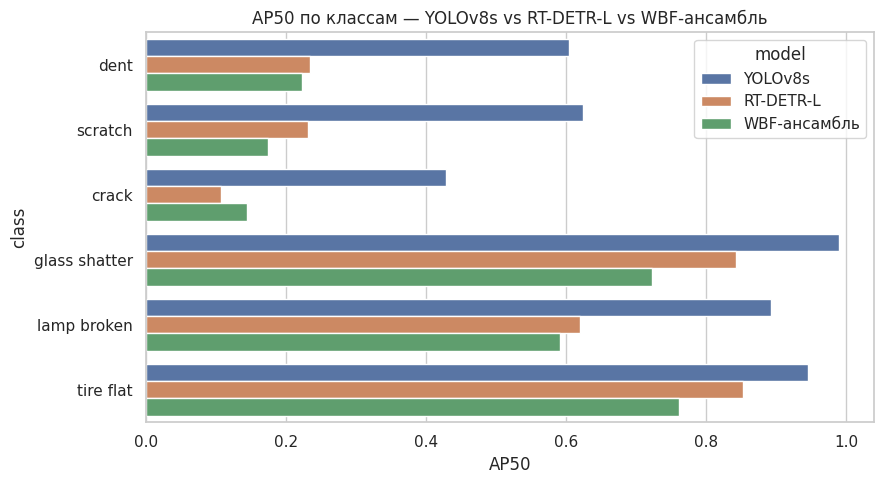

In [18]:
ensemble_per_class = evaluate_map(fused_test, test_gt, test_image_files)
per_class_map_ensemble = ensemble_per_class["map_per_class"].numpy()

per_class_full = pd.DataFrame({
    "class": CLASS_NAMES,
    "YOLOv8s": yolo_per_class["AP50_tta"].values,
    "RT-DETR-L": rtdetr_per_class["AP50_tta"].values,
    "WBF-ансамбль": per_class_map_ensemble,
})
per_class_melted = per_class_full.melt(id_vars="class", var_name="model", value_name="AP50")

fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(data=per_class_melted, x="AP50", y="class", hue="model", ax=ax)
ax.set_title("AP50 по классам — YOLOv8s vs RT-DETR-L vs WBF-ансамбль")
plt.tight_layout()
plt.show()

YOLOv8s везде заметно обгоняет другие модели по результатам

## 12. Выводы

**Индивидуальные модели** 
YOLOv8s test mAP50/mAP50-95 (TTA) = 0.7476/0.5976,
RT-DETR-L (TTA) = 0.6200/0.4814

YOLOv8s заметно точнее — разрыв 13 п.п.по mAP50. Гипотеза: RT-DETR (NMS-free, self-attention с нуля учит
пространственную структуру) на датасете из 4000 изображений и при
незавершенном обучении (остановлена на 16-30 эпохе из 60 запланированных, потому что началось переобучение);
YOLOv8, с встроенной пространственной локальностью через свертки, требует
меньше данных/эпох для сходимости

**WBF-ансамбль** 

Лучший вес YOLOv8/RT-DETR = 0.8/0.2. Test mAP50 = 0.5818,
mAP50-95 = 0.4363 — **хуже** обеих моделей по отдельности, вероятной причиной можно назвать плохую калибровку confidence у RT-DETR, потому что WBF использует эти числа как веса при усреднении координат, и шумная,
уверенность второй модели искажает даже небольшой долей участия итоговый результат в худшую сторону

**TTA отдельно от WBF** 

Дал положительный эффект для обеих моделей по отдельности: YOLOv8s — mAP50 0.7334 → 0.7476 (+1.4 п.п.), RT-DETR-L — mAP50
0.5912 → 0.6200, поэтому TTA — рабочая,
оправданная техника для обеих архитектур, в отличие от WBF-объединения
разных моделей

**Ограничение** 

Сравнение и подбор веса — на одном фиксированном
train/val/test split, без кросс-валидации

**Что можно улучшить дальше** 
Дообучить RT-DETR полные 60 эпох с исправленными LR/warmup с самого начала и проверить, меняется ли картина при лучшей
сходимости, калибровка confidence RT-DETR (temperature scaling) перед
WBF, подбор `iou_thr`/`skip_box_thr` для WBF отдельно от дефолтных значений